
# Importações

In [851]:
import argparse

import os
import sys
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

from pyESN import ESN
from shap.plots import colors
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

MODELOS = ["ESN", "MLP", "RF", "XGBoost"]
OTIMIZADORES = ["PSO", "SA"]
N_ITER = 15
N_SOLUCOES = 15
SEED = 100
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
HORIZONTE = 12


def reset_seed(rnd_seed=SEED):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


def calcular_rrmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)

    mean_y_true = np.mean(y_true)

    rrmse = rmse / mean_y_true
    return rrmse


warnings.filterwarnings("ignore")
reset_seed()

# Carregar Datasets

In [852]:
df = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')
df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,11400.0,2015-02-28,18,22,25,27,692,33,4,18,...,0,1,1,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,18427.0,2015-03-31,12,19,24,26,729,32,2,12,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,14274.0,2015-04-30,13,19,21,24,640,29,6,13,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,11987.0,2015-05-31,7,11,18,23,557,28,9,7,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,9006.0,2015-06-30,4,10,18,22,542,29,1,4,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,5640.0,2024-06-30,0,8,17,20,499,26,1,0,...,1,1,0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,11687.0,2024-07-31,1,9,13,18,413,25,6,1,...,1,1,0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,11129.0,2024-08-31,-3,7,15,21,468,31,1,-3,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,9690.0,2024-09-30,10,13,20,24,591,34,3,10,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


## Normalização

In [853]:
# Repete a normalização para obtermos so scalers correspondentes
scalers = {}
dataframes = []

for campus, dados in df.groupby("CAMPUS"):
    scaler = MinMaxScaler()
    dados[["CONSUMO"]] = scaler.fit_transform(dados[["CONSUMO"]])

    scalers[campus] = scaler
    dataframes.append(dados)

df = pd.concat(dataframes, ignore_index=True)

df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,0.502037,2015-02-28,18,22,25,27,692,33,4,18,...,0,1,1,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,0.846886,2015-03-31,12,19,24,26,729,32,2,12,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,0.643078,2015-04-30,13,19,21,24,640,29,6,13,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,0.530844,2015-05-31,7,11,18,23,557,28,9,7,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,0.384551,2015-06-30,4,10,18,22,542,29,1,4,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,0.359224,2024-06-30,0,8,17,20,499,26,1,0,...,1,1,0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,1.000000,2024-07-31,1,9,13,18,413,25,6,1,...,1,1,0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,0.940871,2024-08-31,-3,7,15,21,468,31,1,-3,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,0.788386,2024-09-30,10,13,20,24,591,34,3,10,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


## Criação dos Lags

In [854]:
dataframes = []

for campus, dados in df.sort_values("DATA").groupby("CAMPUS"):
    lags = {f'LAG_{i:02d}': dados['CONSUMO'].shift(i) for i in range(1, 12 + 1)}
    dados = pd.concat([dados, pd.DataFrame(lags)], axis=1)
    dados.dropna(inplace=True)
    dados["ORDEM"] = range(1, len(dados) + 1)
    dataframes.append(dados)

df = pd.concat(dataframes, ignore_index=True)
df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,LAG_03,LAG_04,LAG_05,LAG_06,LAG_07,LAG_08,LAG_09,LAG_10,LAG_11,LAG_12
0,0.615105,2016-02-29,19,22,25,28,734,33,4,19,...,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886,0.502037
1,0.711047,2016-03-31,12,17,22,28,685,32,3,12,...,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886
2,0.633361,2016-04-30,4,9,23,28,702,33,2,4,...,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078
3,0.406291,2016-05-31,4,11,16,22,490,27,9,4,...,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844
4,0.362467,2016-06-30,-1,7,14,20,408,27,3,-1,...,0.711047,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090,0.359224,2024-06-30,0,8,17,20,499,26,1,0,...,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248,0.743880
2091,1.000000,2024-07-31,1,9,13,18,413,25,6,1,...,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248
2092,0.940871,2024-08-31,-3,7,15,21,468,31,1,-3,...,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038
2093,0.788386,2024-09-30,10,13,20,24,591,34,3,10,...,0.359224,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059


## Melhores Features

In [855]:
df_features = pd.read_csv("./resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_features = df_features.columns

df_features

Index(['TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'PRECIPITAÇÃO_MÉD_MENS',
       'TEMP_MIN_MAX_MENS', 'TEMP_MAX_MIN_MENS', 'PRECIPITAÇÃO_MIN_MENS',
       'TEMP_MAX_MAX_MENS', 'DIA_DA_SEMANA_dom', 'DIA_DA_SEMANA_seg',
       'DIA_DA_SEMANA_sáb', 'DIA_DA_SEMANA_ter', 'MÊS_abr', 'MÊS_ago',
       'MÊS_fev', 'MÊS_jun', 'MÊS_mai', 'MÊS_nov', 'ANO_2021', 'ANO_2022',
       'ANO_2023', 'ANO_2015', 'ANO_2016', 'ANO_2017', 'ANO_2018', 'ANO_2019',
       'CAMPUS_ASTORGA', 'CAMPUS_CAMPO LARGO', 'CAMPUS_CAPANEMA',
       'CAMPUS_CASCAVEL', 'CAMPUS_CORONEL VIVIDA', 'CAMPUS_CURITIBA',
       'CAMPUS_GOIOERÊ', 'CAMPUS_IVAIPORÃ', 'CAMPUS_JAGUARIAÍVA',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_PALMAS', 'CAMPUS_PARANAGUÁ',
       'CAMPUS_PINHAIS', 'CAMPUS_TELÊMACO BORBA', 'CAMPUS_UMUARAMA',
       'CURSOS_TEC_SUBSEQUENTE', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'CURSOS_GRAD_NOTURNO', 'CURSOS_POS', 'FÉRIAS',
       'COVID', 'LAG_01', 'LAG_02', 'LAG_03', 'LAG_05', 'LAG_07', 'LAG_09'],


## Melhores Parâmetros

In [856]:
def get_modelo(nome):
    if nome == "ESN":
        return ESN(n_inputs=df_features.shape[0],
                   n_outputs=1,
                   n_reservoir=int(best["ESN"]["Reservoirs"]),
                   sparsity=best["ESN"]["Sparsity"],
                   spectral_radius=best["ESN"]["Spectral Radius"],
                   random_state=SEED)

    if nome == "MLP":
        mlp = MLPRegressor(hidden_layer_sizes=(int(best["MLP"]["Hidden Layers"]),),
                           activation=best["MLP"]["Activation"],
                           alpha=best["MLP"]["Alpha"],
                           random_state=SEED)
        return mlp

    if nome == "RF":
        return RandomForestRegressor(random_state=SEED,
                                     n_estimators=int(best["RF"]["N_estimators"]),
                                     max_depth=int(best["RF"]["Max_depth"]),
                                     min_samples_split=int(best["RF"]["Min_samples_split"]),
                                     min_samples_leaf=int(best["RF"]["Min_samples_leaf"]))

    if nome == "XGBoost":
        updater = "coord_descent" if best["XGBoost"]["Booster"] == "gblinear" else None
        return XGBRegressor(random_state=SEED,
                            n_estimators=int(best["XGBoost"]["N_estimators"]),
                            max_depth=int(best["XGBoost"]["Max_depth"]),
                            booster=best["XGBoost"]["Booster"],
                            reg_lambda=best["XGBoost"]["Lambda"],
                            reg_alpha=best["XGBoost"]["Alpha"],
                            updater=updater)


best = {}
for modelo in MODELOS:
    df_aux = pd.DataFrame()
    for otimizador in OTIMIZADORES:
        for seed in SEEDS:
            try:
                new_df = pd.read_csv(f'resultados/otimização - regressão/{otimizador}-{modelo} SEED {seed}.csv',
                                     sep=";",
                                     decimal=".",
                                     header=0)
                df_aux = pd.concat([df_aux, new_df], axis=0)
            except Exception as e:
                continue
    df_aux = df_aux.sort_values(by=["Fitness"])
    df_aux[df_aux.isnull()] = None
    best[f"{modelo}"] = df_aux[:1].iloc[0].to_dict()

for key, val in best.items():
    print(f"{key}")
    display(val)

ESN


{'Unnamed: 0': 10.0,
 'Reservoirs': 11.0,
 'Sparsity': 0.2301,
 'Spectral Radius': 0.6392,
 'Fitness': 0.2890811074595547}

MLP


{'Unnamed: 0': 12,
 'Hidden Layers': 220,
 'Alpha': 0.9787414053993986,
 'Activation': 'relu',
 'Fitness': 0.2270813337813527}

RF


{'Unnamed: 0': 14.0,
 'N_estimators': 15.0,
 'Max_depth': 232.0,
 'Min_samples_split': 11.0,
 'Min_samples_leaf': 4.0,
 'Fitness': 0.246877008396465}

XGBoost


{'Unnamed: 0': 14,
 'N_estimators': 242,
 'Max_depth': 119,
 'Booster': 'gbtree',
 'Lambda': 0.898,
 'Alpha': 0.0408,
 'Fitness': 0.2429799856272088}

# Treino e Teste

In [857]:
def treino(previsor, dados_treino, features):
    x_treino = dados_treino[features].to_numpy()
    y_treino = dados_treino["CONSUMO"].to_numpy()

    previsor.fit(x_treino, y_treino)
    return previsor


def teste(previsor, historico_campus, dados_teste, features):
    historico = historico_campus[["CONSUMO"]].copy()
    x_teste = dados_teste[features].copy()

    previsoes = []

    for i_test in range(HORIZONTE):
        row = x_teste.iloc[[i_test]].copy()
        historico = pd.concat([historico, pd.DataFrame([0], columns=["CONSUMO"], index=[i_test])], axis=0)

        # Recalcula os lags conforme os valores previstos pelo modelo
        lags = pd.DataFrame({f'LAG_{i:02d}': historico["CONSUMO"].shift(i) for i in range(1, 12 + 1) if
                             f'LAG_{i:02d}' in features}).tail(1)
        row.update(lags)

        prev = previsor.predict(row.to_numpy())[0]
        row["CONSUMO"] = prev
        previsoes.append(prev)
        historico.update(row)

    return pd.DataFrame({"CONSUMO PREVISTO": previsoes}, index=dados_teste.index)

## Divisão dos Dados


In [858]:
dataframes_treino = []
dataframes_teste = []

for campus, dados in df.sort_values('DATA').groupby("CAMPUS"):
    dados["CAMPUS"] = campus

    dados_treino, dados_teste = train_test_split(dados, test_size=HORIZONTE, random_state=SEED, shuffle=False)

    dataframes_treino.append(dados_treino)
    dataframes_teste.append(dados_teste)

df_treino = pd.DataFrame(pd.concat(dataframes_treino, ignore_index=True))
df_teste = pd.DataFrame(pd.concat(dataframes_teste, ignore_index=True))




## Treinamento Local

In [859]:

for campus, dados_teste in df_teste.sort_values("DATA").groupby("CAMPUS"):
    df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste["DATA"])

    for nome_modelo in MODELOS:
        # Treina o modelo com os dados do campus atual
        dados_treino = df_treino[df_treino["CAMPUS"] == campus]
        modelo = treino(get_modelo(nome_modelo), dados_treino, df_features)

        # Testa o modelo com os dados do campus atual
        previsoes = teste(modelo, dados_treino, dados_teste, df_features)
        df_previsoes[[nome_modelo]] = scalers[campus].inverse_transform(previsoes[["CONSUMO PREVISTO"]])

    df_previsoes.to_csv(f"resultados/regressão - local/{HORIZONTE}M - {campus}.csv", sep=";", decimal=".",
                        index=True)


## Treinamento Global

In [860]:

for campus, dados_teste in df_teste.sort_values("DATA").groupby("CAMPUS"):
    df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste["DATA"])

    # Reordena o dataframe de treino para que o campus atual seja o último
    for nome_modelo in MODELOS:
        # Treina o modelo com os dados de todos os campi
        modelo = treino(get_modelo(nome_modelo), df_treino, df_features)

        # Testa o modelo com os dados do campus atual
        previsoes = teste(modelo, df_treino[df_treino["CAMPUS"] == campus], dados_teste, df_features)
        df_previsoes[[nome_modelo]] = scalers[campus].inverse_transform(previsoes[["CONSUMO PREVISTO"]])

    df_previsoes.to_csv(f"resultados/regressão - global/{HORIZONTE}M - {campus}.csv", sep=";", decimal=".",
                        index=True)



# Análise dos Resultados

In [861]:
def ts_comparacao(campus, valor_real, valores_previstos, erros):
    valor_real = valor_real.tail(HORIZONTE)
    plt.figure(figsize=(12, 4.5))
    plt.rcParams['xtick.labelsize'] = 13
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams.update({'font.size': 12})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["blue", "green", "darkgoldenrod", colors.red_rgb, "purple", "cyan", "slategrey", "coral"])

    for nome_modelo in valores_previstos.columns:
        plt.plot(valores_previstos[nome_modelo],
                 label=f"{nome_modelo} - {campus} (RRMSE: {erros.loc[nome_modelo]["RRMSE"]:.2%})")

    plt.plot(valor_real["CONSUMO"], label=f"CONSUMO REAL - {campus}", color="black")

    plt.xlabel('Mês')
    plt.ylabel('Consumo (KWh)')

    ax = plt.gca()
    ax.set_facecolor('white')

    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white')

    return plt


def medidas_erro(valor_real, valores_previstos):
    df_desempenho = pd.DataFrame(columns=["MAPE", "RRMSE"], index=valores_previstos.columns)

    for nome_modelo in valores_previstos.columns:
        df_desempenho.loc[nome_modelo] = [
            mape(valor_real["CONSUMO"].tail(HORIZONTE), valores_previstos[nome_modelo].tail(HORIZONTE)),
            calcular_rrmse(valor_real["CONSUMO"].tail(HORIZONTE), valores_previstos[nome_modelo].tail(HORIZONTE))
        ]

    return df_desempenho


## Treinamento Local

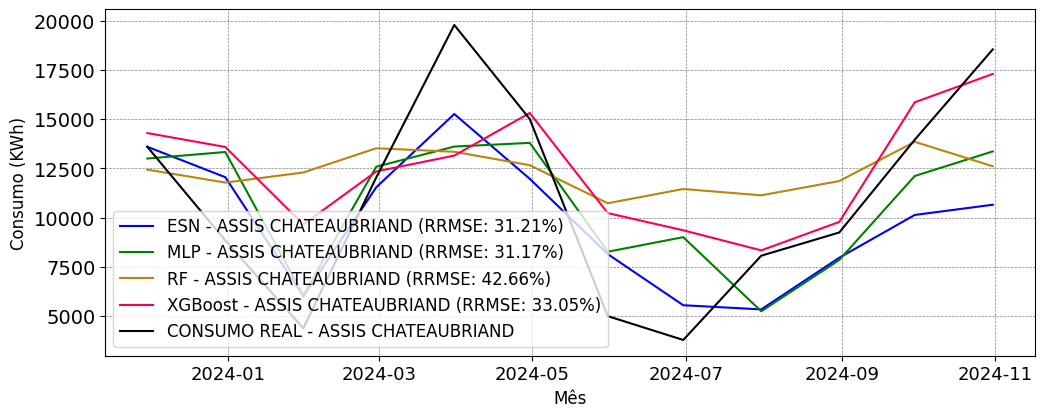

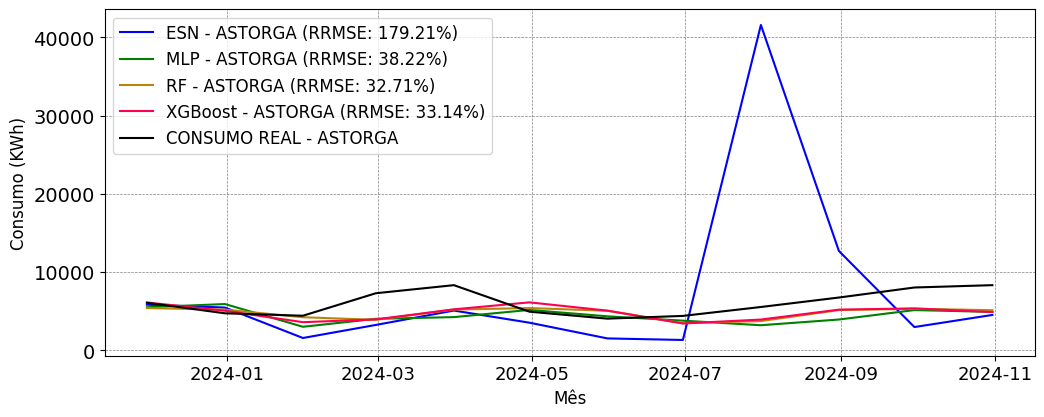

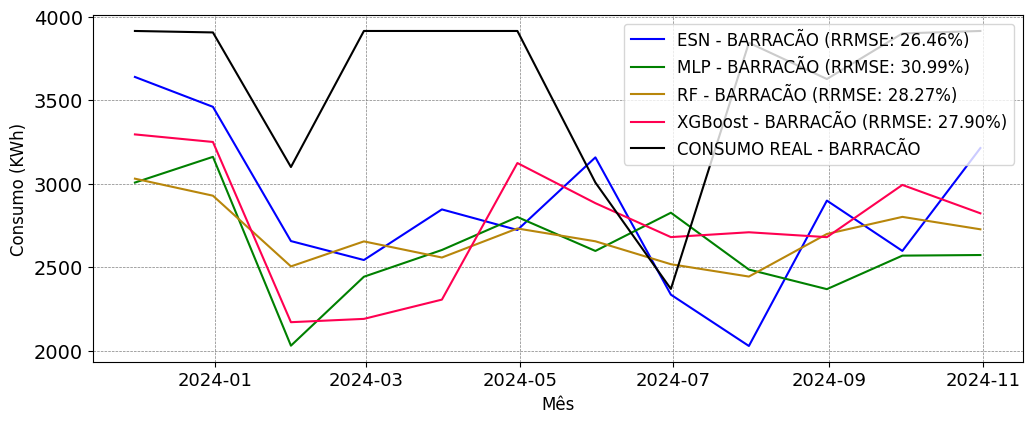

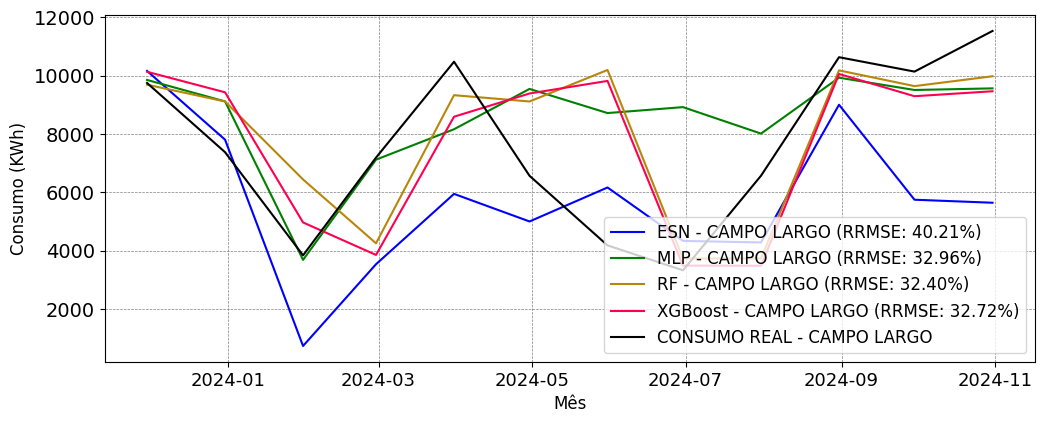

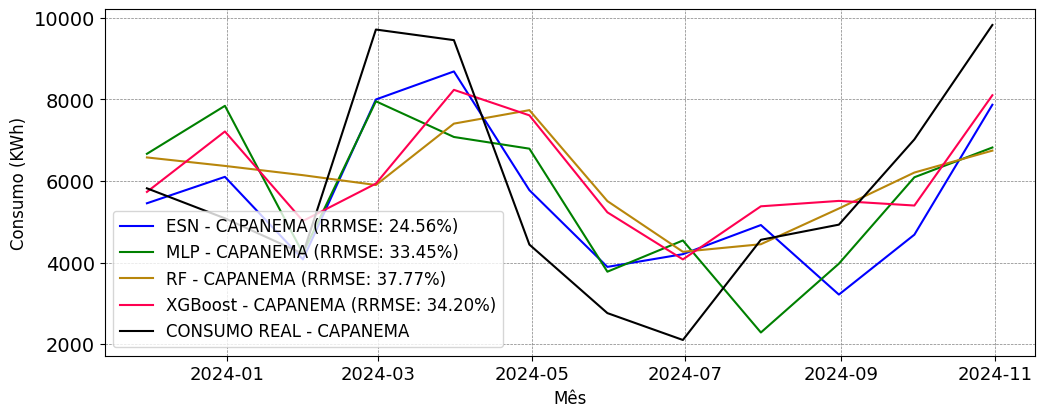

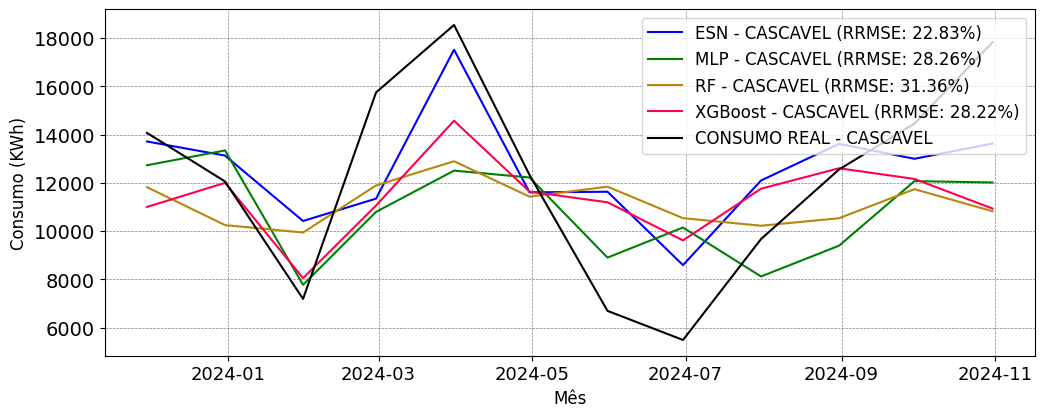

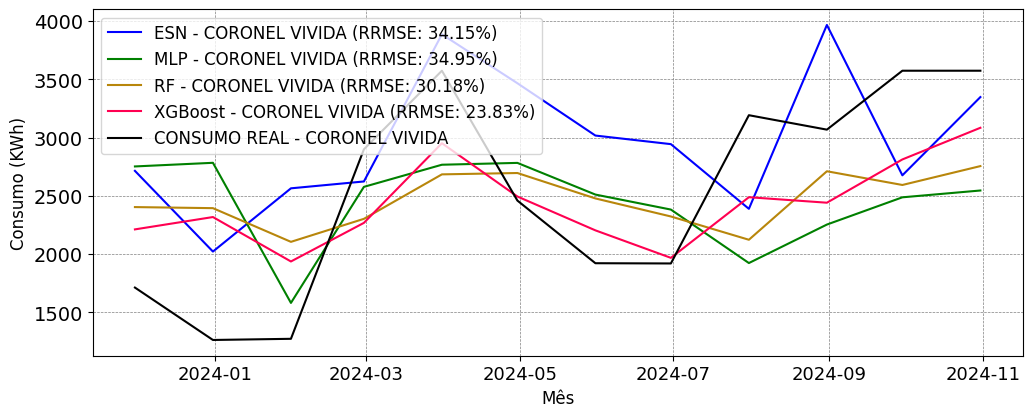

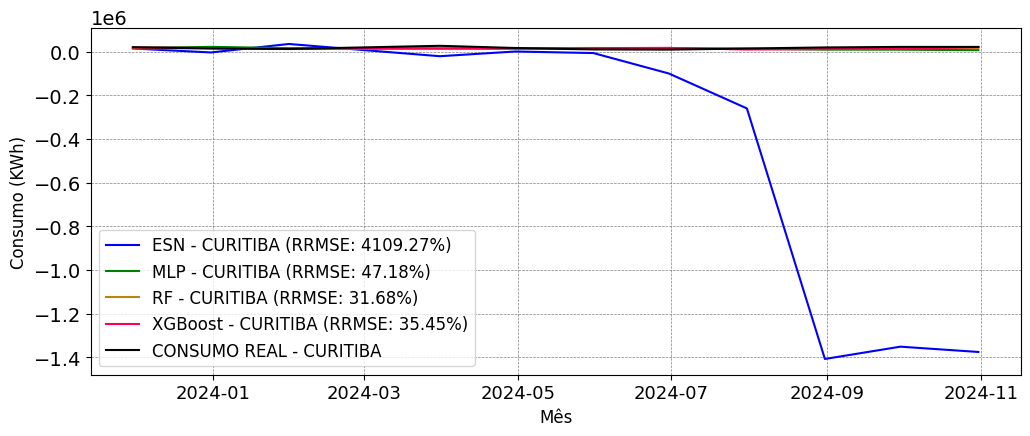

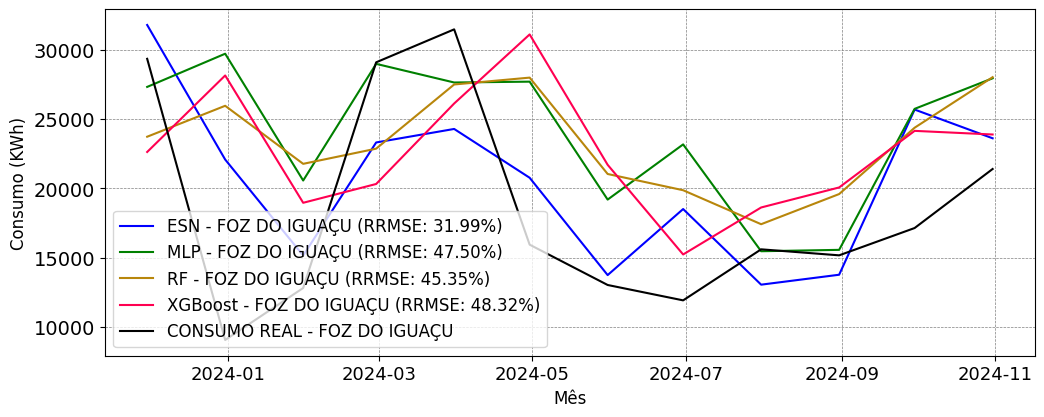

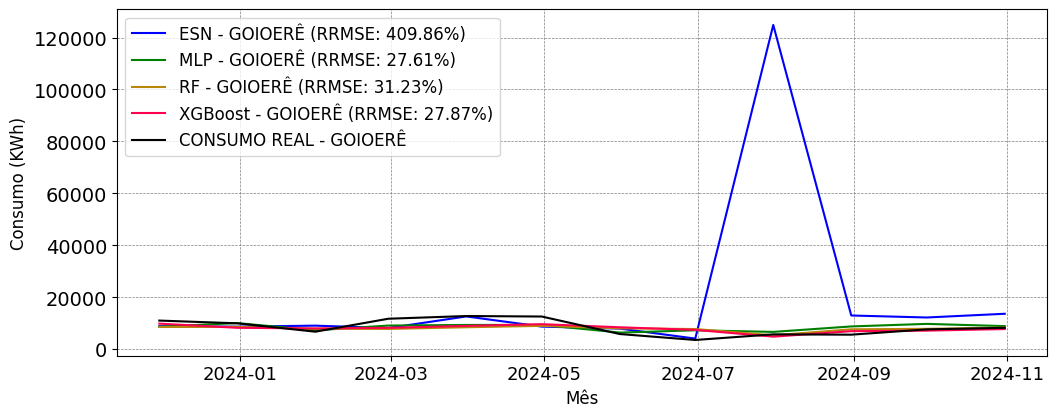

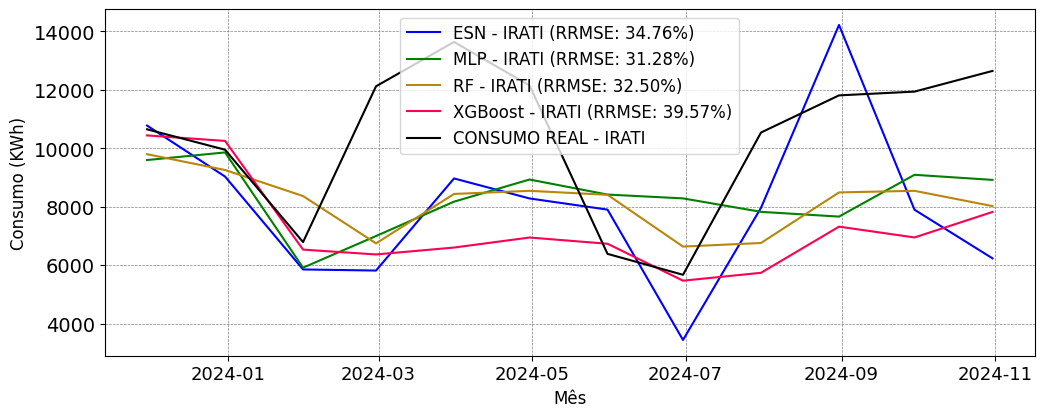

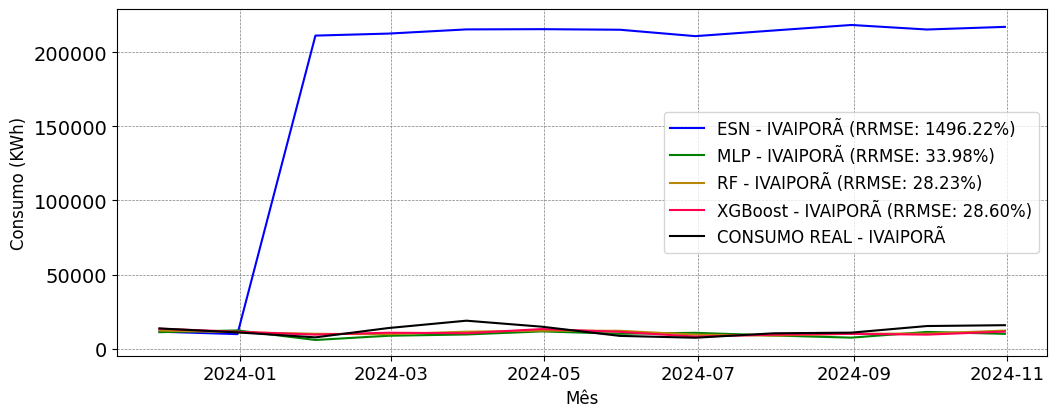

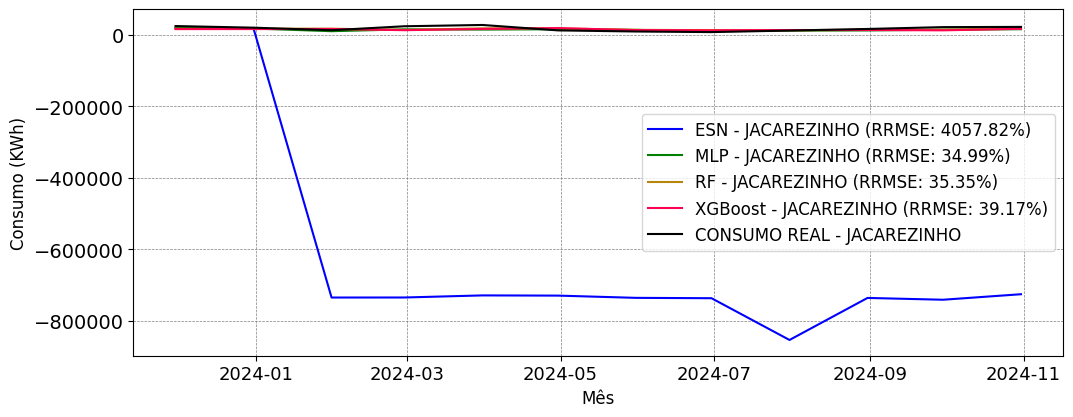

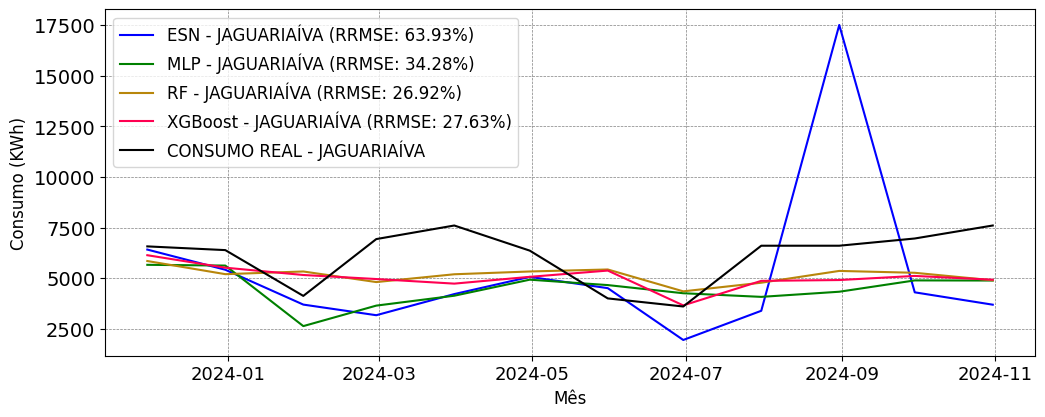

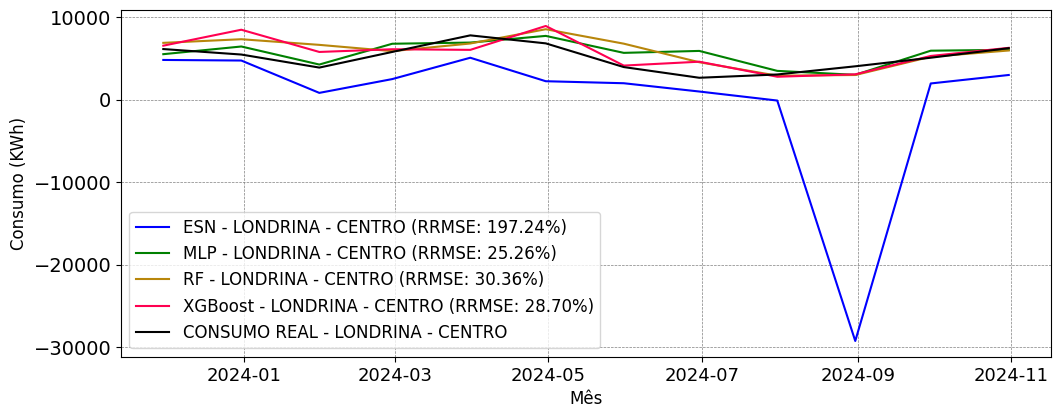

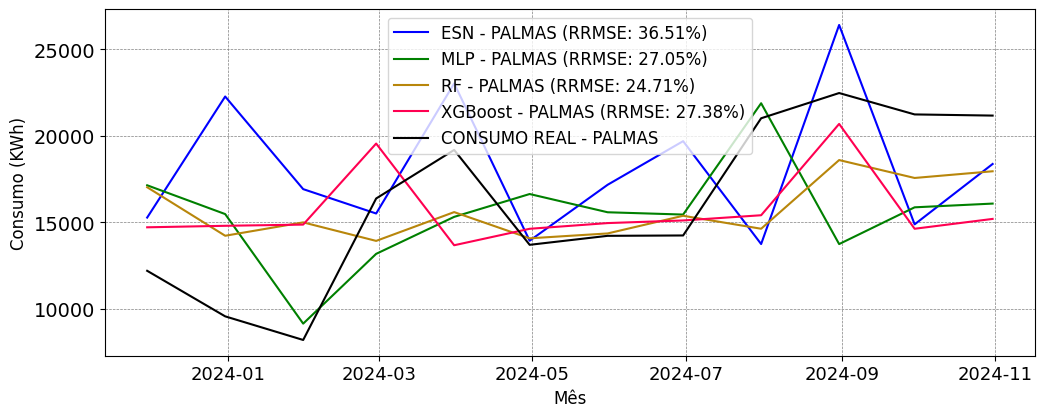

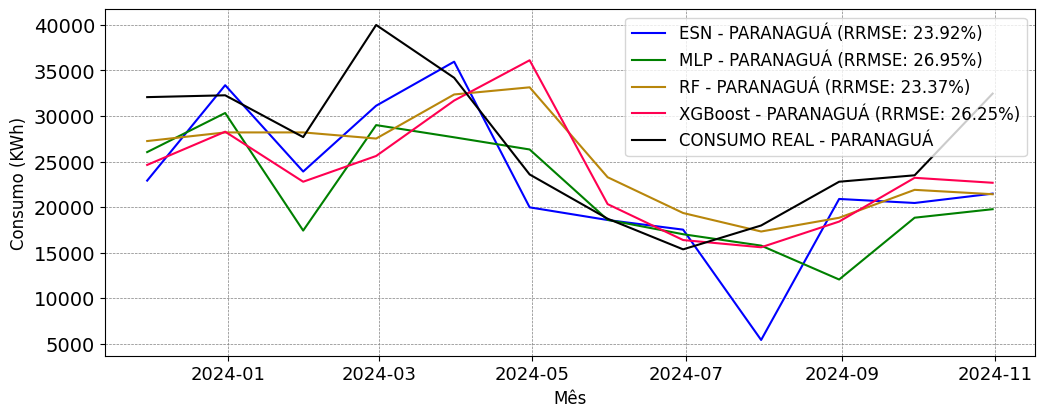

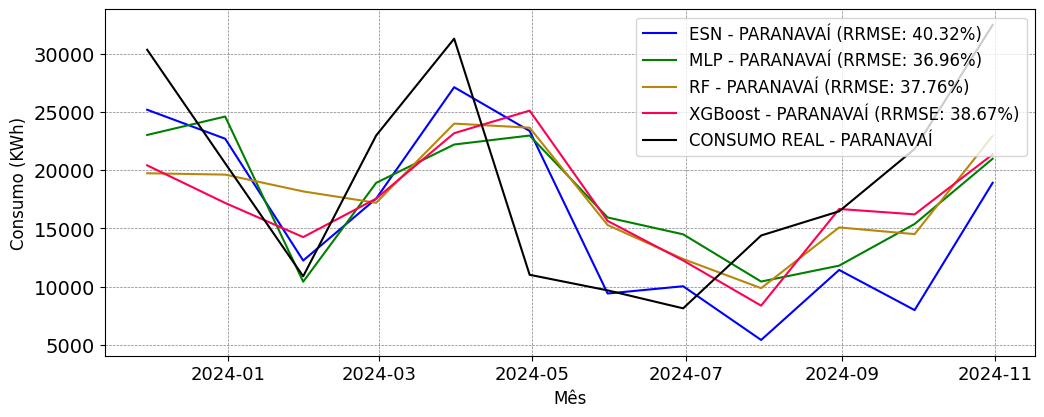

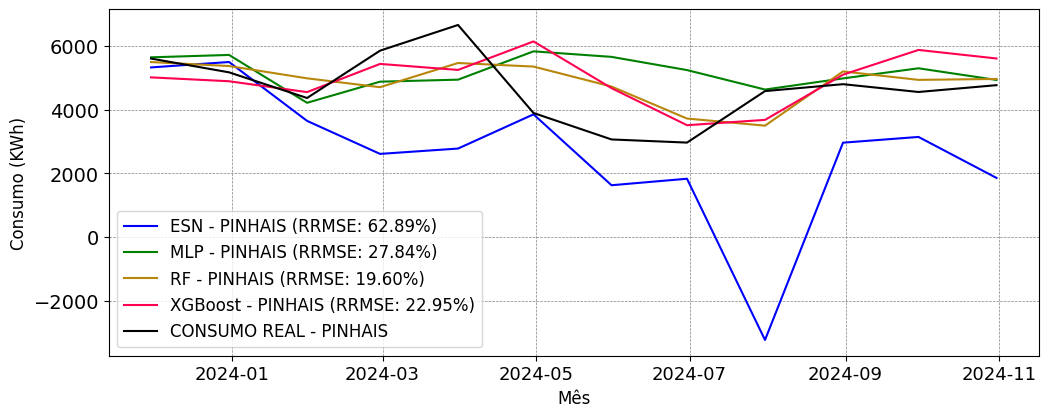

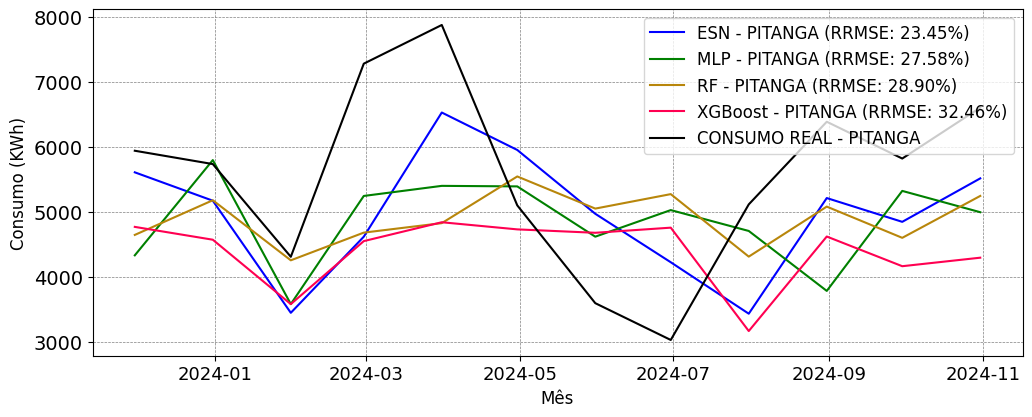

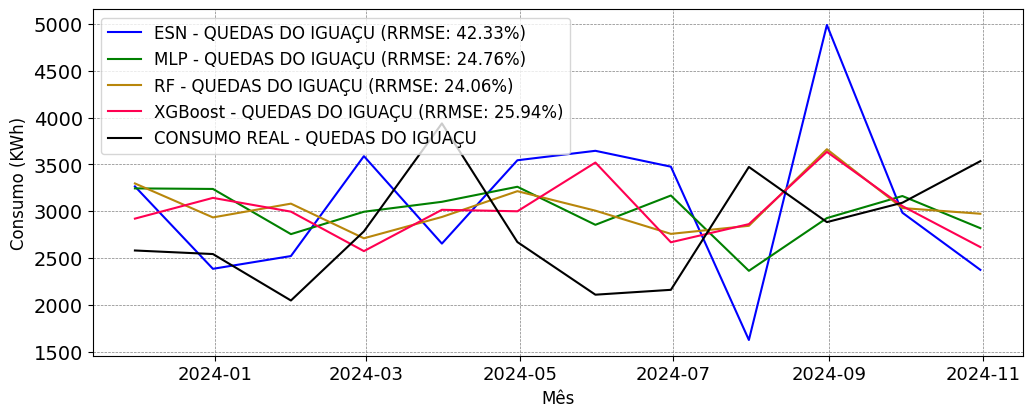

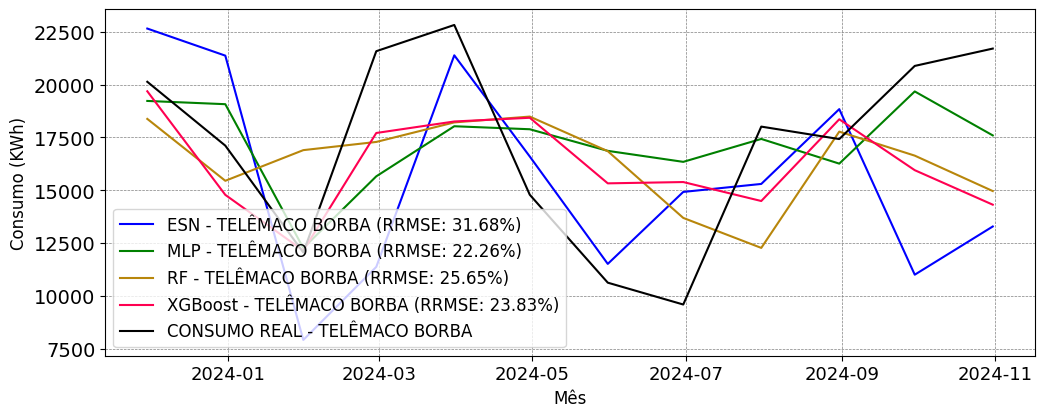

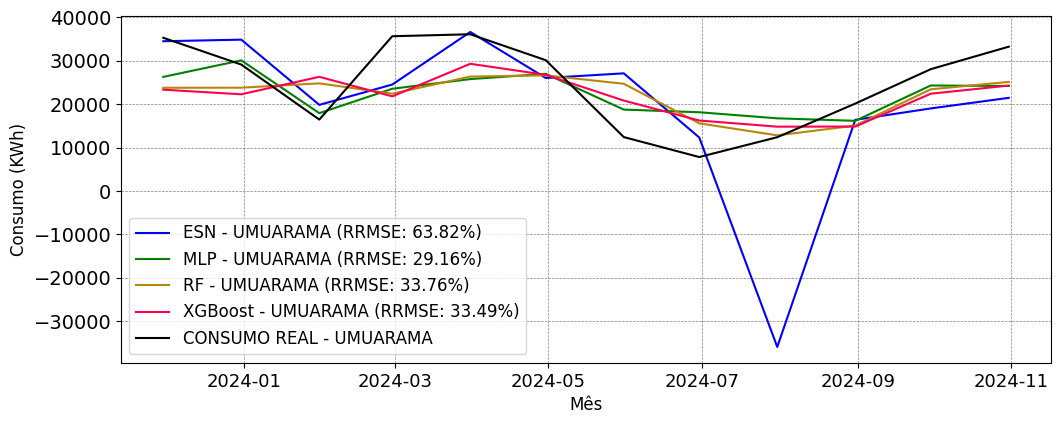

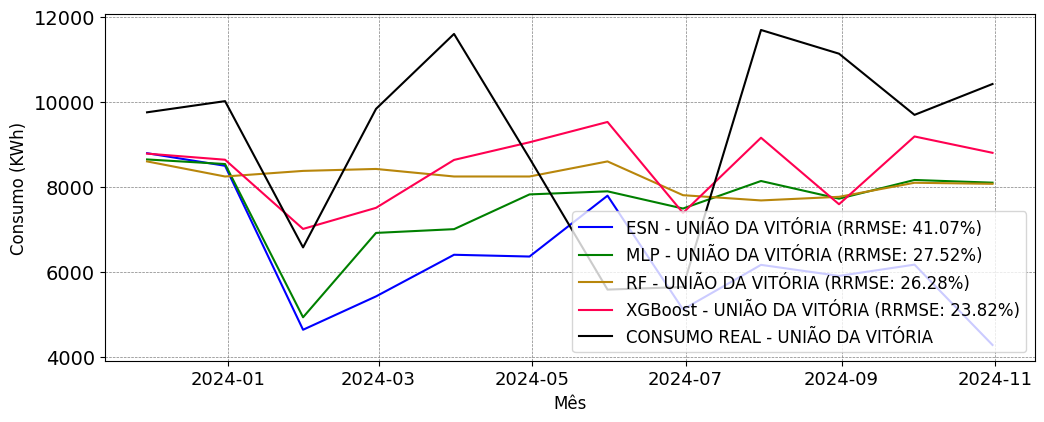

,ESN,MLP,RF,XGBoost
ASSIS CHATEAUBRIAND,0.312148,0.311652,0.426601,0.330532
ASTORGA,1.792133,0.382215,0.327119,0.331436
BARRACÃO,0.26461,0.309925,0.282723,0.278976
CAMPO LARGO,0.402085,0.329562,0.323969,0.327186
CAPANEMA,0.24563,0.33448,0.37766,0.341955
CASCAVEL,0.228254,0.282599,0.313594,0.282178
CORONEL VIVIDA,0.341468,0.349451,0.301824,0.238297
CURITIBA,41.092744,0.471826,0.316789,0.354452
FOZ DO IGUAÇU,0.319853,0.474964,0.453511,0.483163
GOIOERÊ,4.098625,0.276056,0.312324,0.278742


In [862]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')

df_RRMSE = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())

for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
    try:
        consumo_previsto = pd.read_csv(f"resultados/regressão - local/{HORIZONTE}M - {campus}.csv",
                                       sep=";", decimal=".", header=0)
    except Exception as e:
        continue

    consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
    consumo_previsto = consumo_previsto.set_index("DATA")

    dados["DATA"] = pd.to_datetime(dados["DATA"])
    dados = dados.set_index("DATA")

    df_erros = medidas_erro(dados, consumo_previsto)
    df_RRMSE.loc[campus] = df_erros["RRMSE"]

    plt = ts_comparacao(campus, dados, consumo_previsto, df_erros)

    df_erros.to_csv(f"resultados/desempenho regressão - local/{HORIZONTE}M {campus}.csv",
                    sep=";", decimal=".", index=True)
    plt.savefig(f"resultados/desempenho regressão - local/{HORIZONTE}M {campus}.png",
                bbox_inches='tight')
    plt.show()

df_RRMSE.loc["MÉDIA"] = df_RRMSE.mean()
df_RRMSE


## Treinamento Global

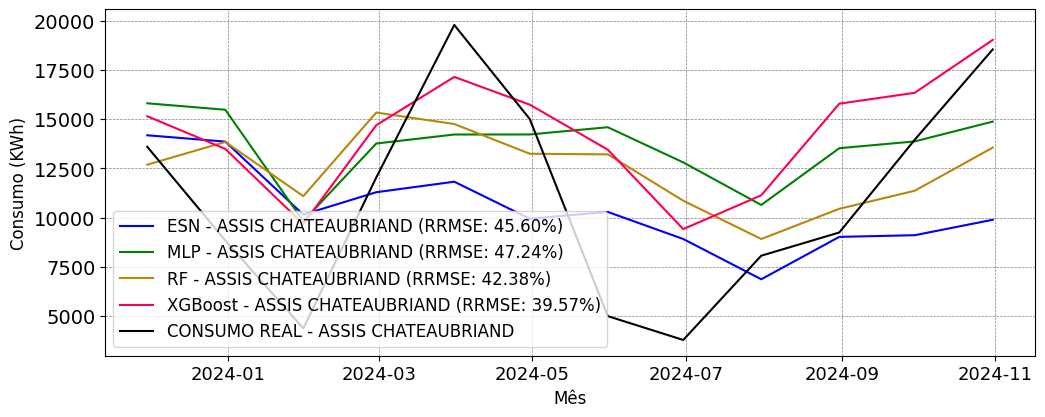

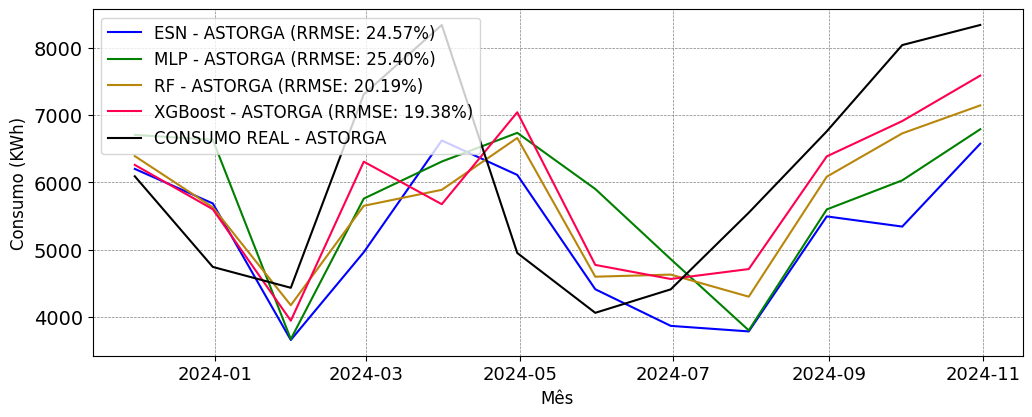

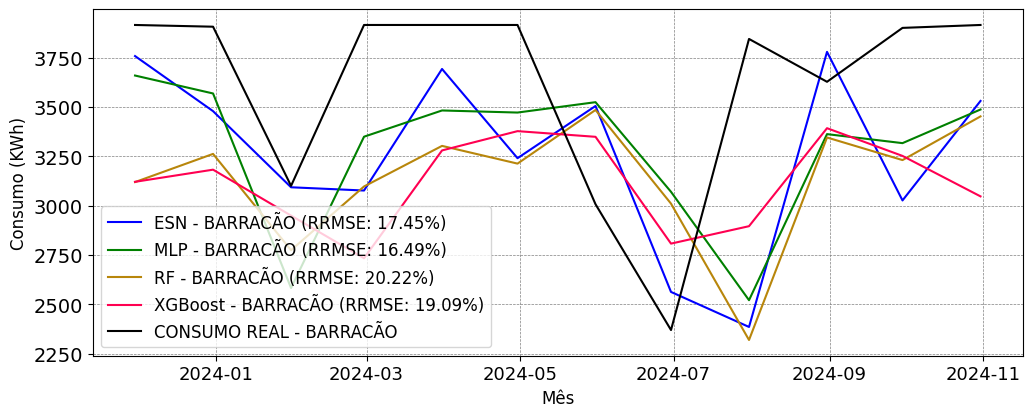

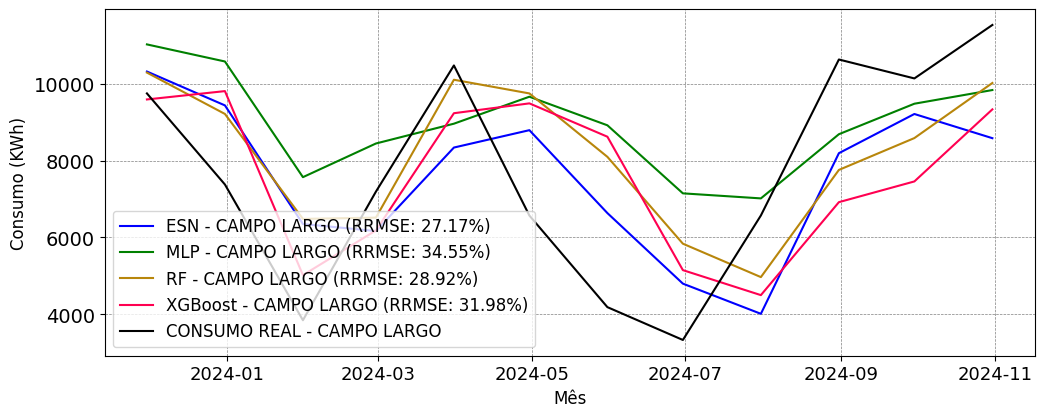

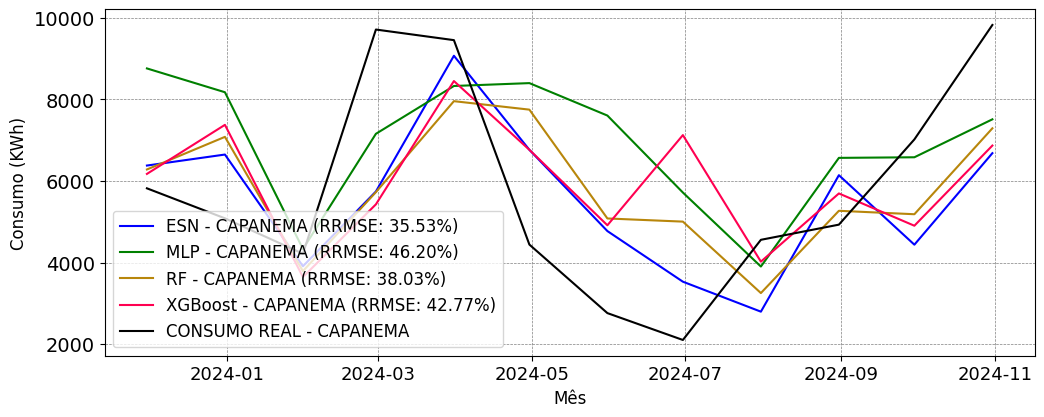

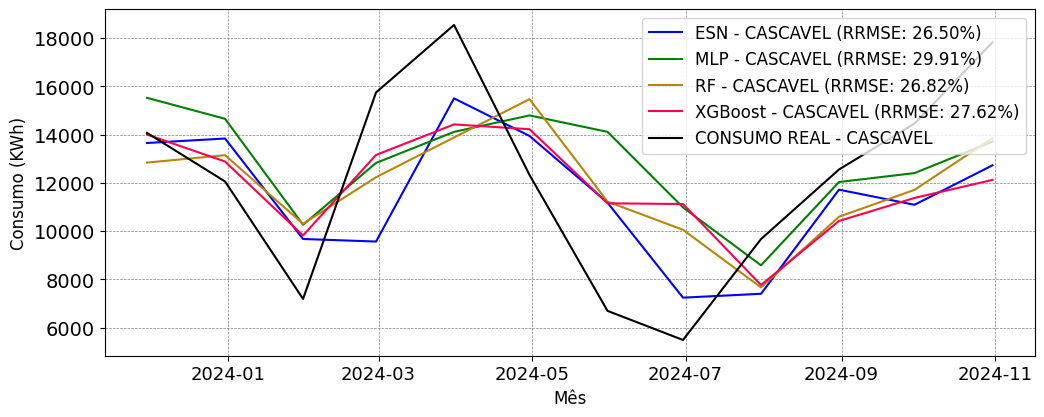

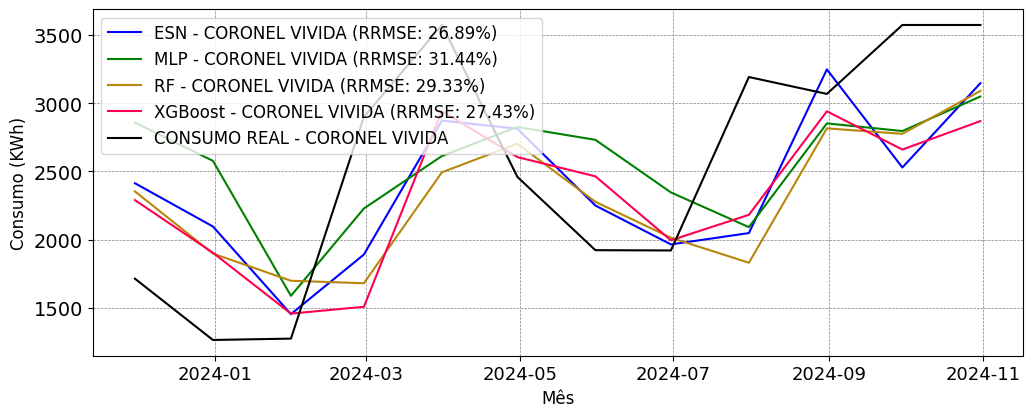

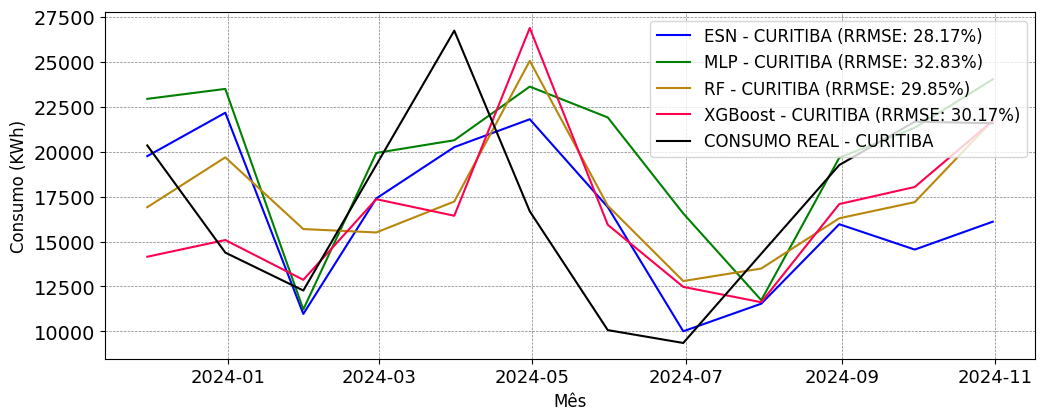

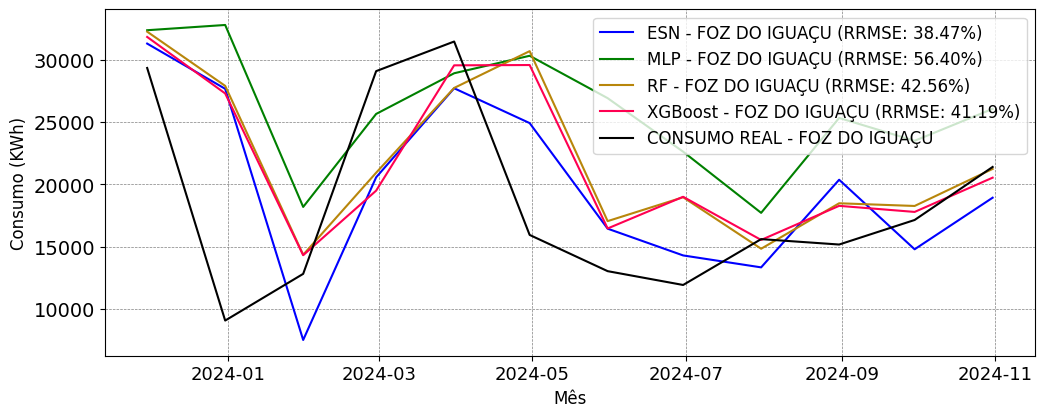

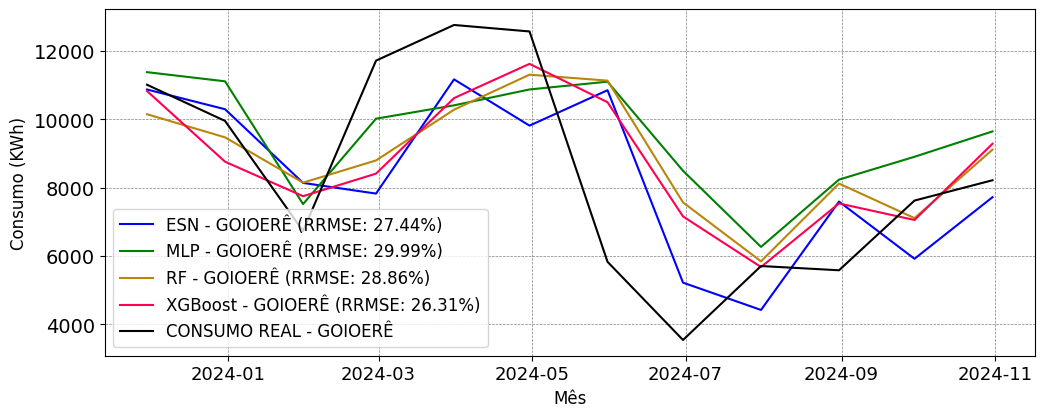

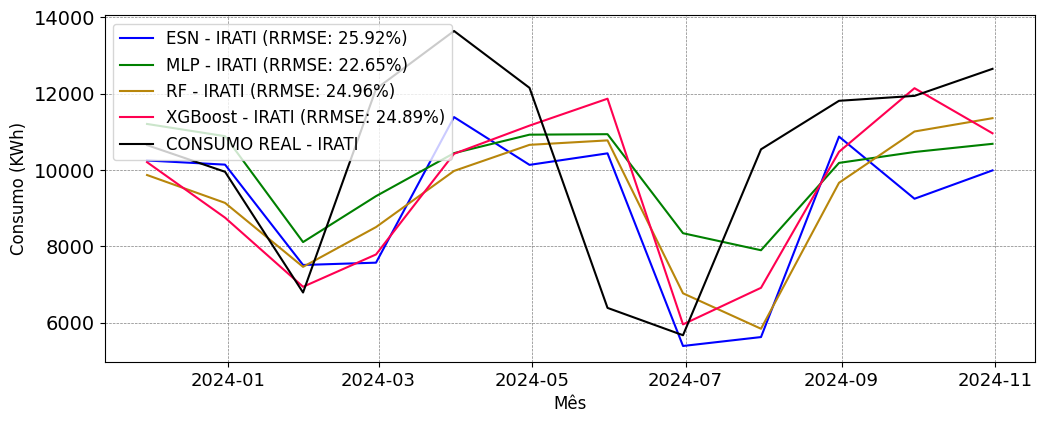

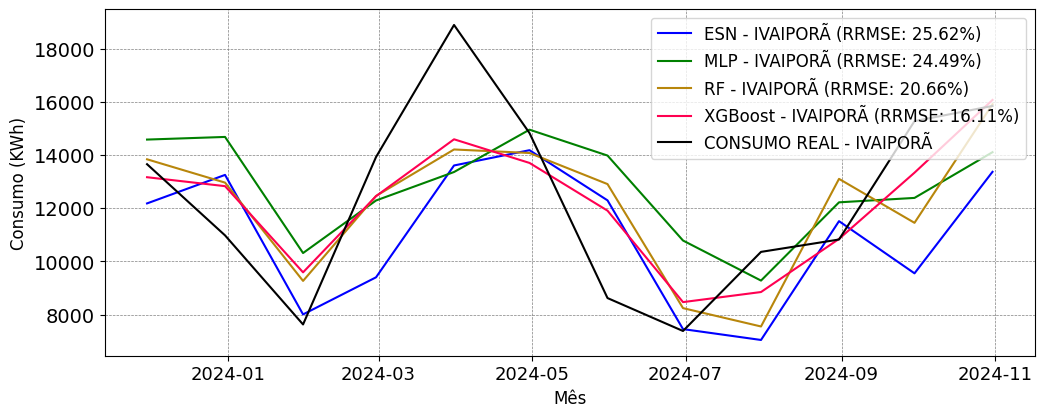

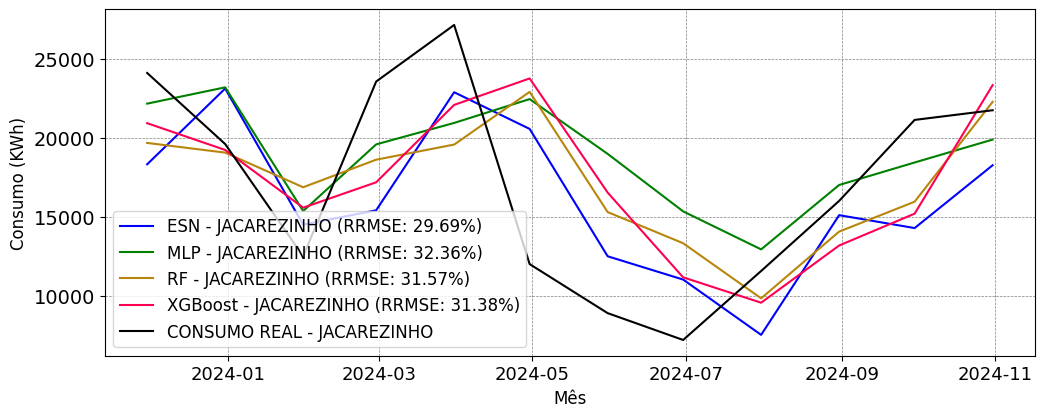

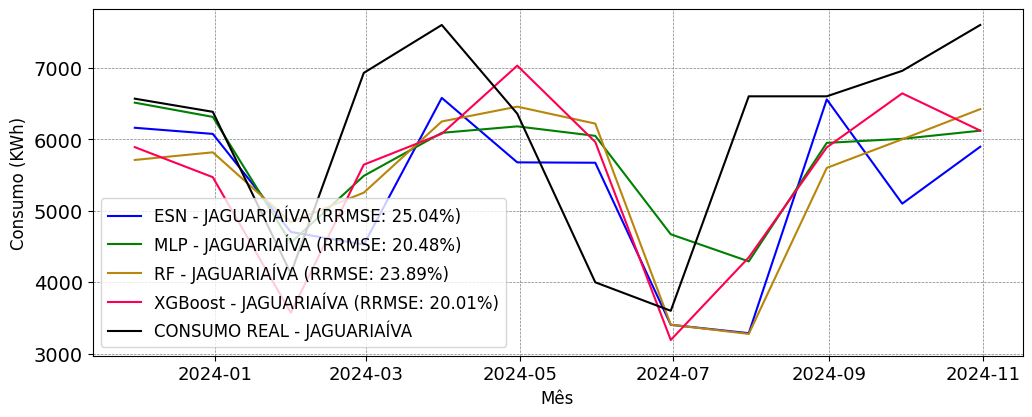

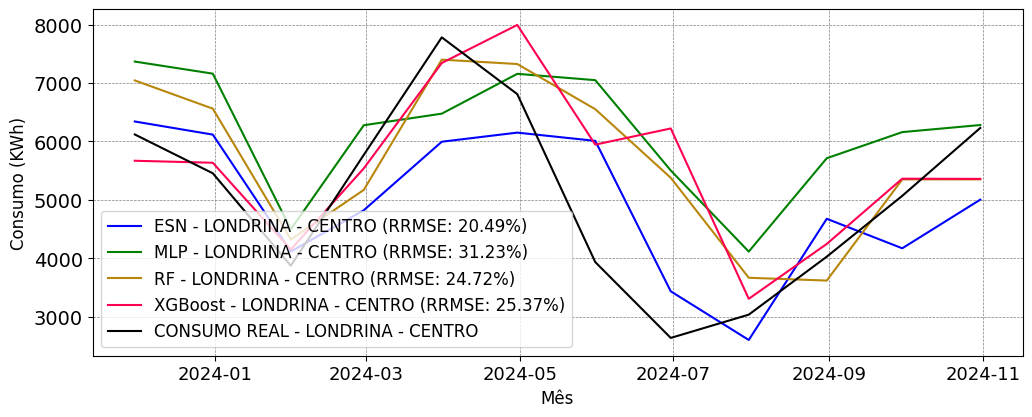

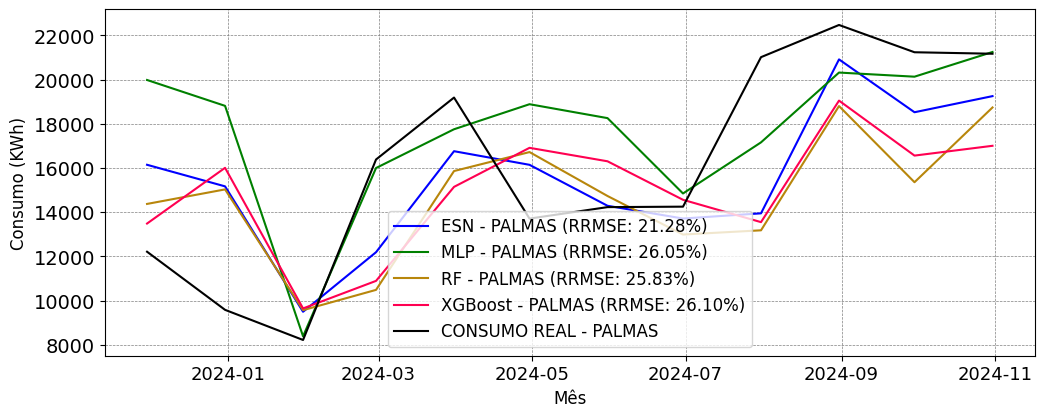

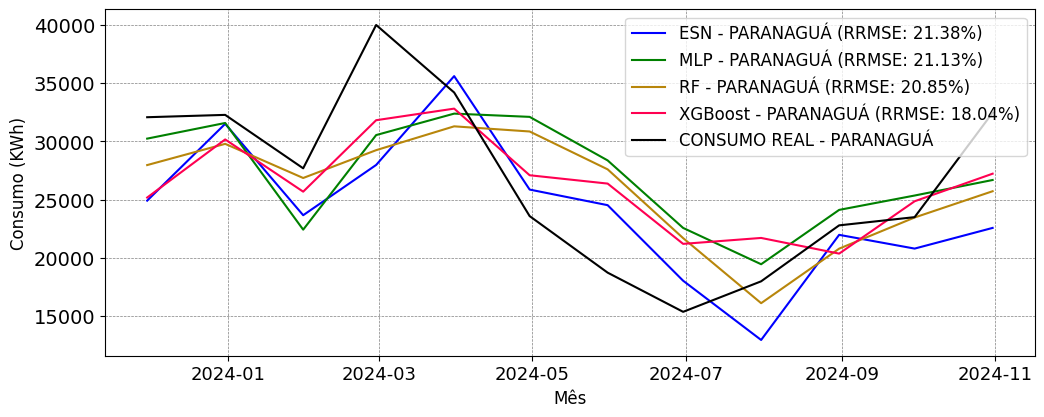

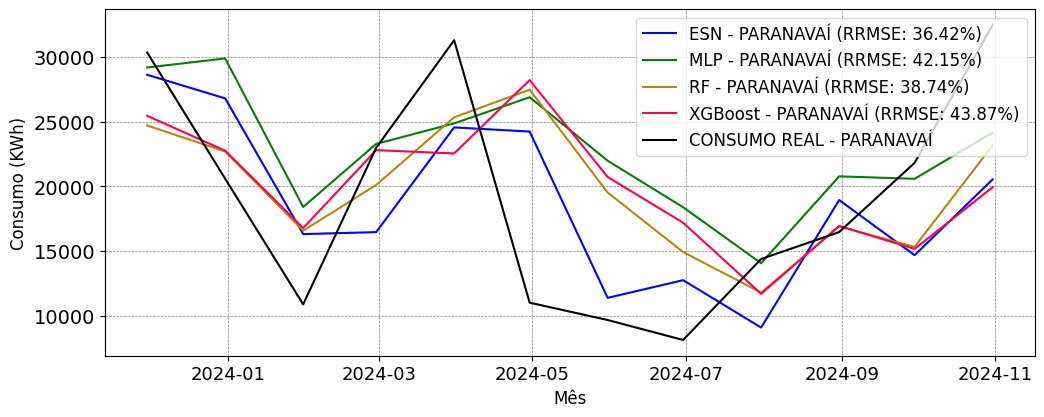

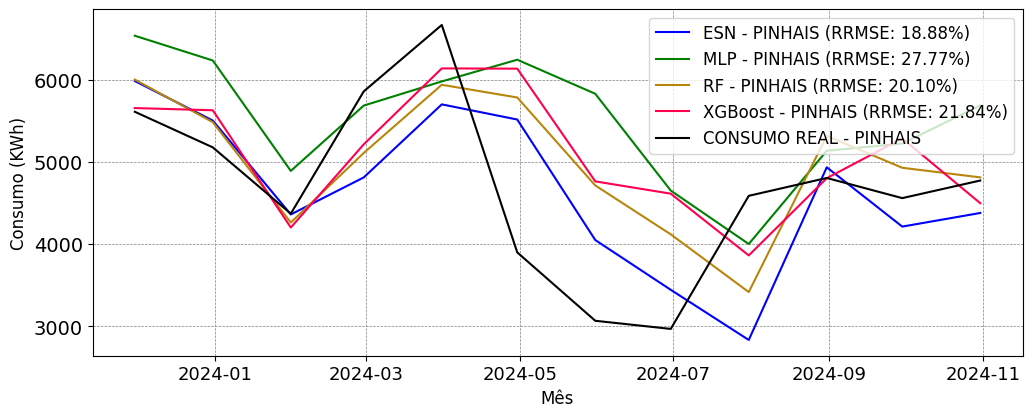

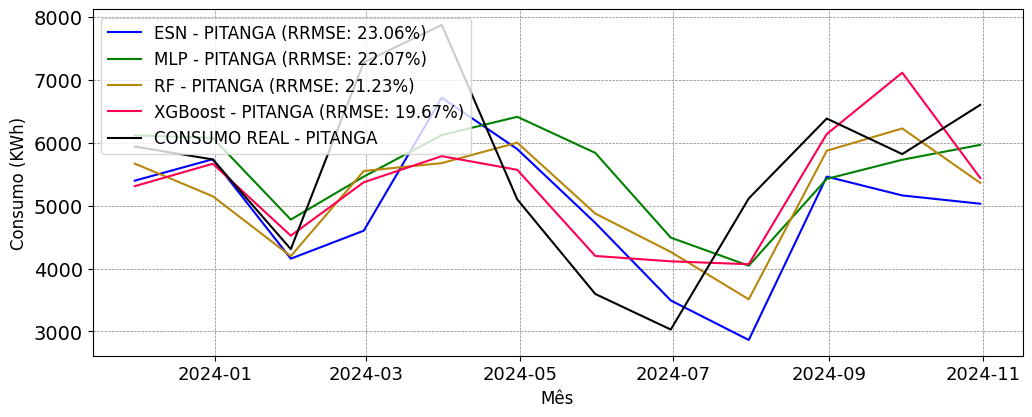

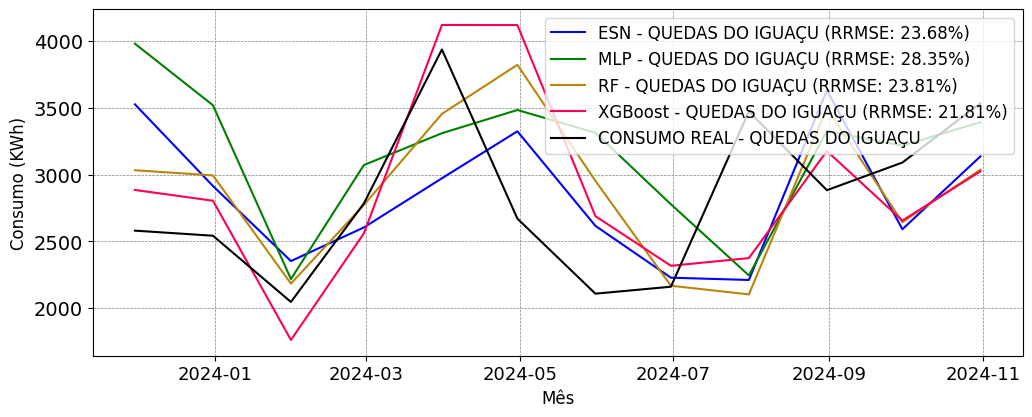

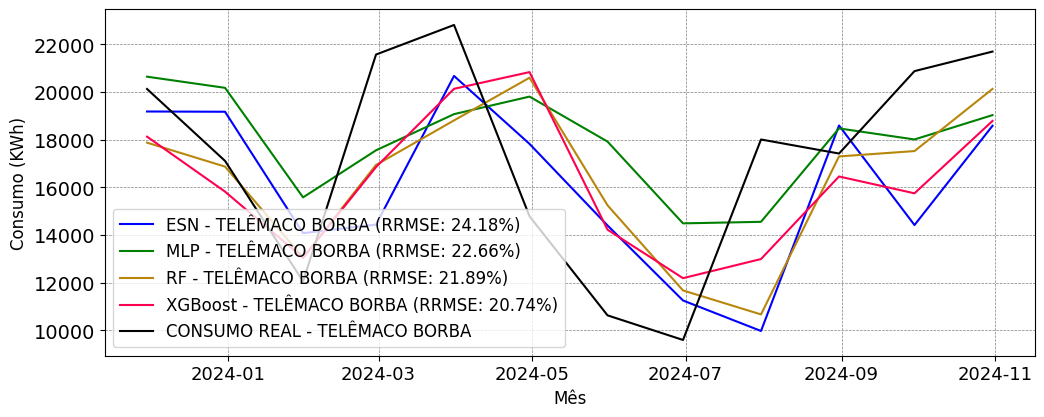

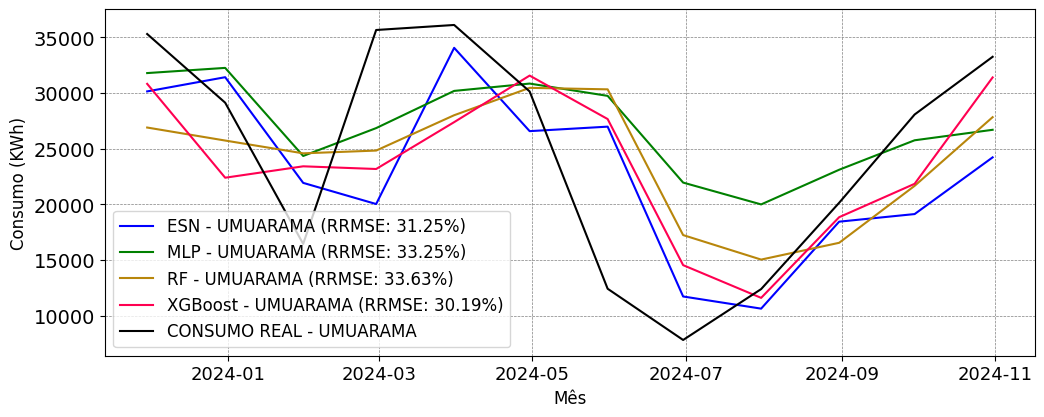

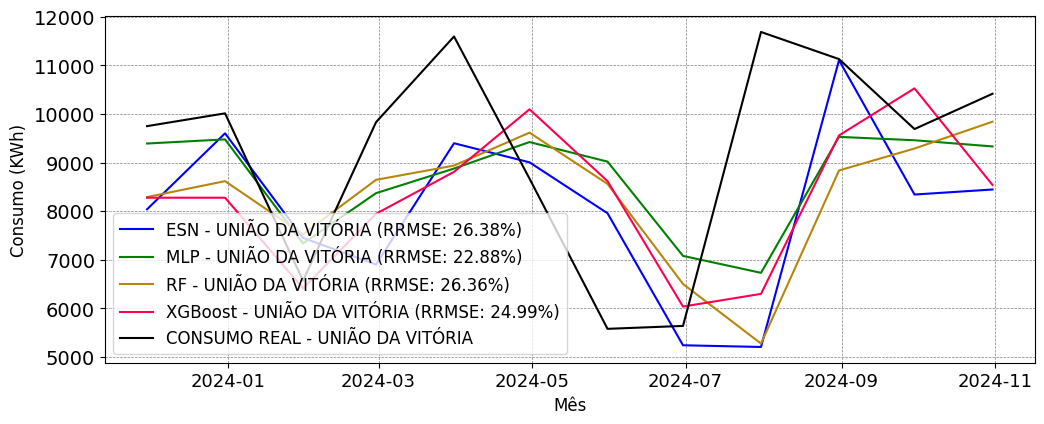

,ESN,MLP,RF,XGBoost
ASSIS CHATEAUBRIAND,0.455958,0.47242,0.423841,0.39571
ASTORGA,0.245677,0.254017,0.201889,0.193776
BARRACÃO,0.174458,0.164873,0.202164,0.190909
CAMPO LARGO,0.271674,0.345537,0.289163,0.319845
CAPANEMA,0.355251,0.461969,0.380335,0.427661
CASCAVEL,0.26504,0.299144,0.268187,0.276161
CORONEL VIVIDA,0.268939,0.314391,0.293273,0.274295
CURITIBA,0.281655,0.32828,0.298507,0.301707
FOZ DO IGUAÇU,0.384728,0.564002,0.425646,0.411893
GOIOERÊ,0.274383,0.299864,0.288643,0.263094


In [863]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')

df_RRMSE = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())

for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
    try:
        consumo_previsto = pd.read_csv(f"resultados/regressão - global/{HORIZONTE}M - {campus}.csv",
                                       sep=";", decimal=".", header=0)
    except Exception as e:
        continue

    consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
    consumo_previsto = consumo_previsto.set_index("DATA")

    dados["DATA"] = pd.to_datetime(dados["DATA"])
    dados = dados.set_index("DATA")

    df_erros = medidas_erro(dados, consumo_previsto)
    df_RRMSE.loc[campus] = df_erros["RRMSE"]

    plt = ts_comparacao(campus, dados, consumo_previsto, df_erros)

    df_erros.to_csv(f"resultados/desempenho regressão - global/{HORIZONTE}M {campus}.csv",
                    sep=";", decimal=".", index=True)
    plt.savefig(f"resultados/desempenho regressão - global/{HORIZONTE}M {campus}.png",
                bbox_inches='tight')
    plt.show()

df_RRMSE.loc["MÉDIA"] = df_RRMSE.mean()
df_RRMSE
